🎬 MOVIE DATASET ANALYSIS - ART HOUSE CONTROVERSY

📂 Loading data from Desktop...
✓ Loaded: 50000 movies with 23 columns

Columns: ['titleId', 'imdbUrl', 'originalTitle', 'titleType', 'releaseYear', 'runtimeMinutes', 'isAdult', 'imdbRating', 'numberOfVotes', 'allCountries', 'mainCountry', 'allLanguages', 'firstLanguage', 'englishTitle', 'topFiveActors', 'directors', 'writers', 'plotShort', 'plotMedium', 'plotLong', 'genres', 'keywords', 'production']

✓ Filtered to: 19700 movies with complete data

🔥 TOP 30 MOST CONTROVERSIAL MOVIES (ART HOUSE GOLD)
(High votes + Low rating = POLARIZING, perfect for art house)

1. "Harry Potter and the Sorcerer's Stone"
   🗳️  Votes: 884,416 | ⭐ Rating: 7.7 | 🔥 Controversy: 1.78
   🔑 Keywords: magic, wizard, orphan, school of magic, based on novel, train, unicorn...

2. "Gravity"
   🗳️  Votes: 870,521 | ⭐ Rating: 7.7 | 🔥 Controversy: 1.75
   🔑 Keywords: space station, female protagonist, sole survivor, self sacrifice, long...

3. "The Shining"
   🗳️  Vo

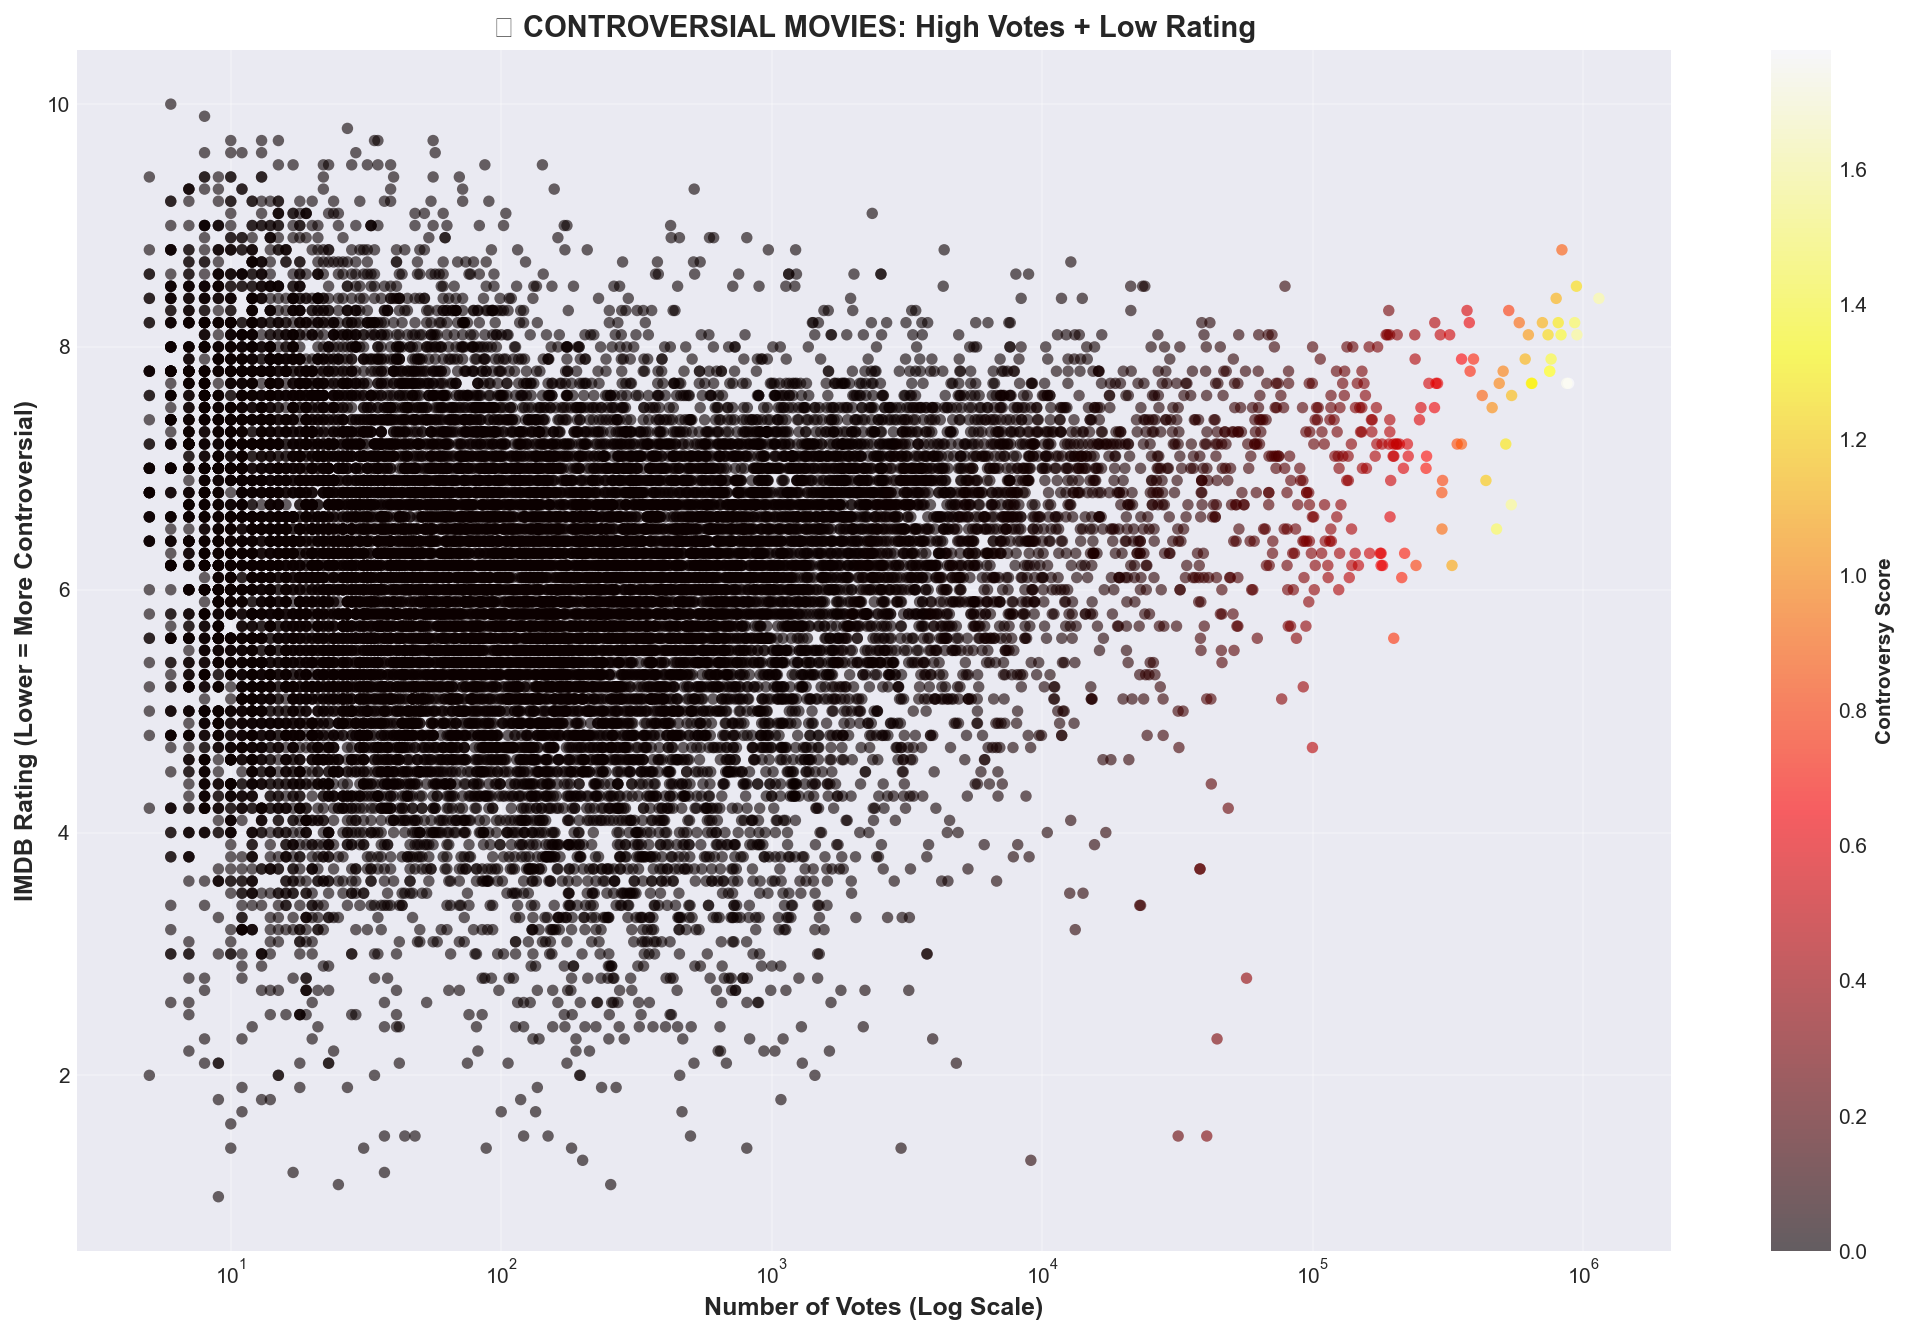

   ✓ Saved: 01_controversy_scatter.png

📈 Graph 2/8: Top Controversial Keywords...


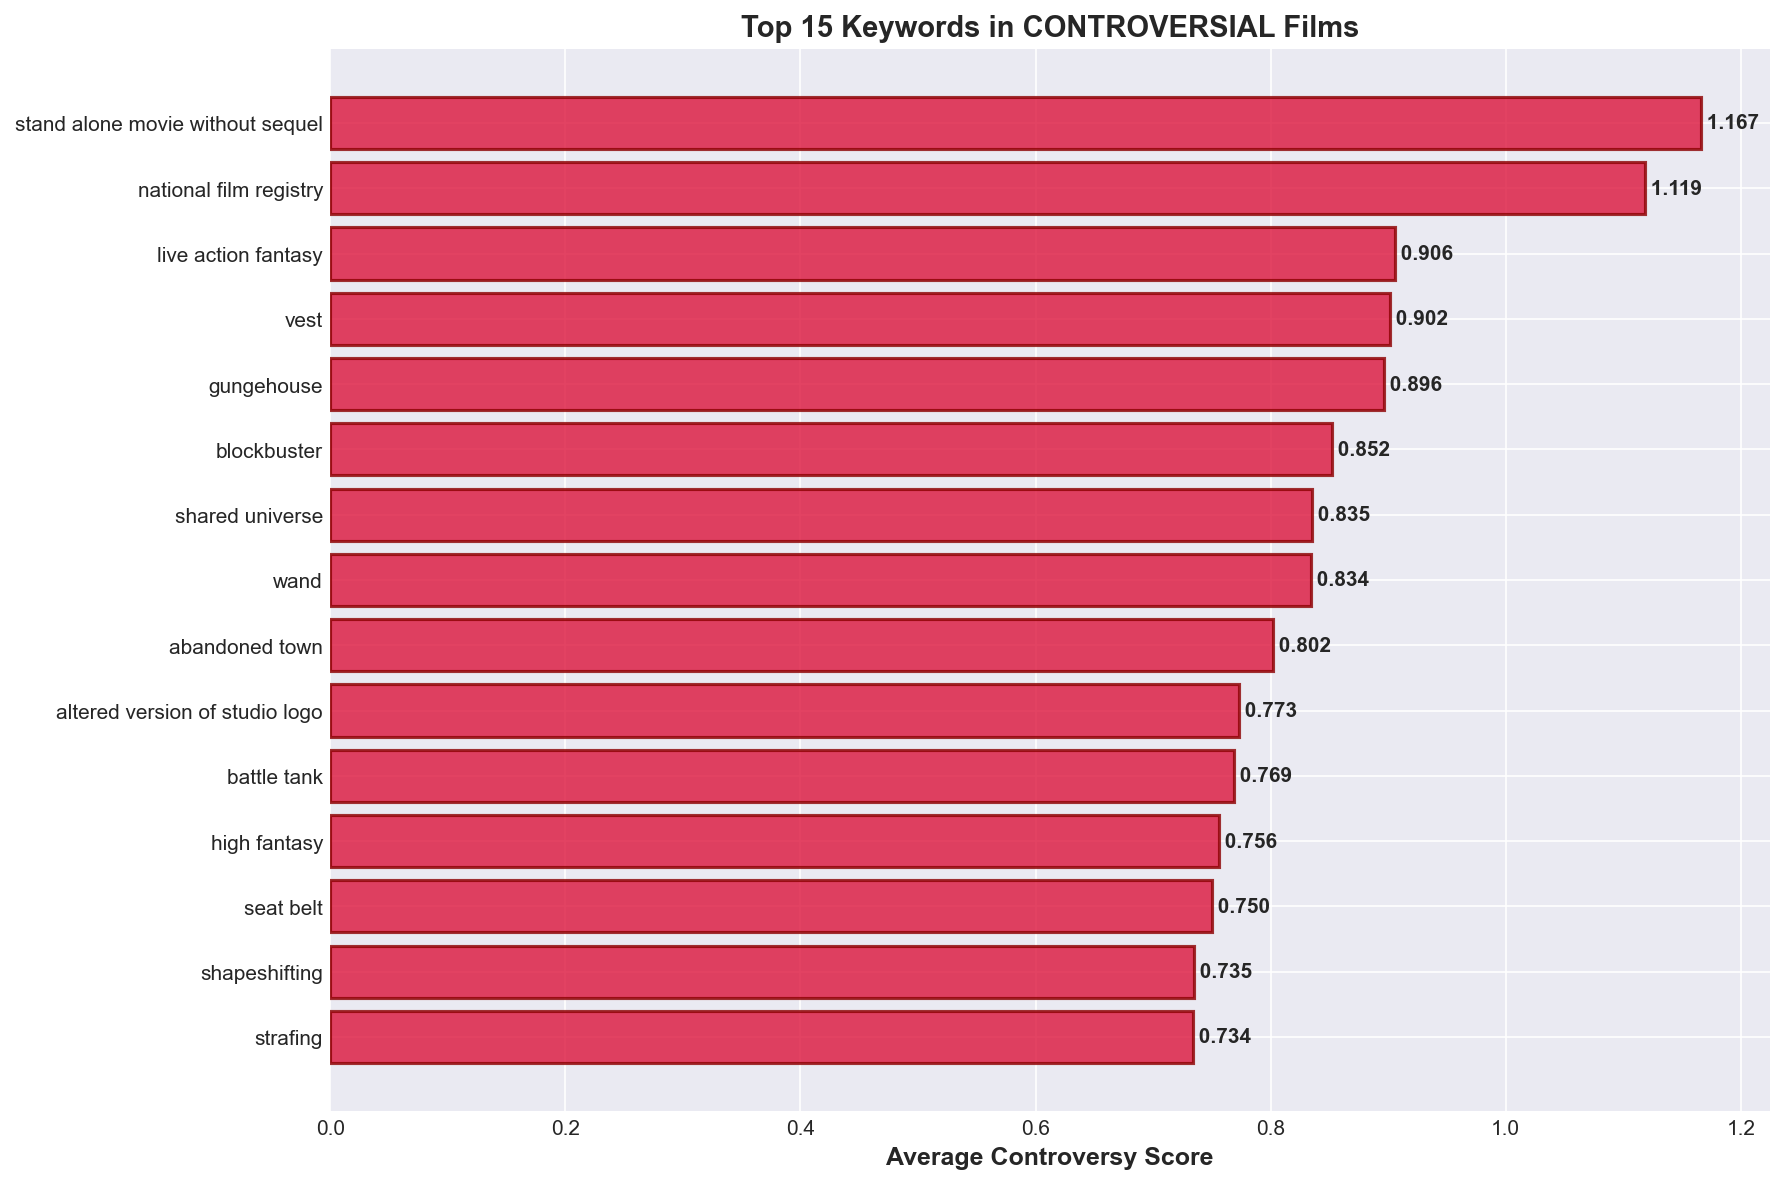

   ✓ Saved: 02_controversial_keywords_bar.png

📈 Graph 3/8: Rating Distribution...


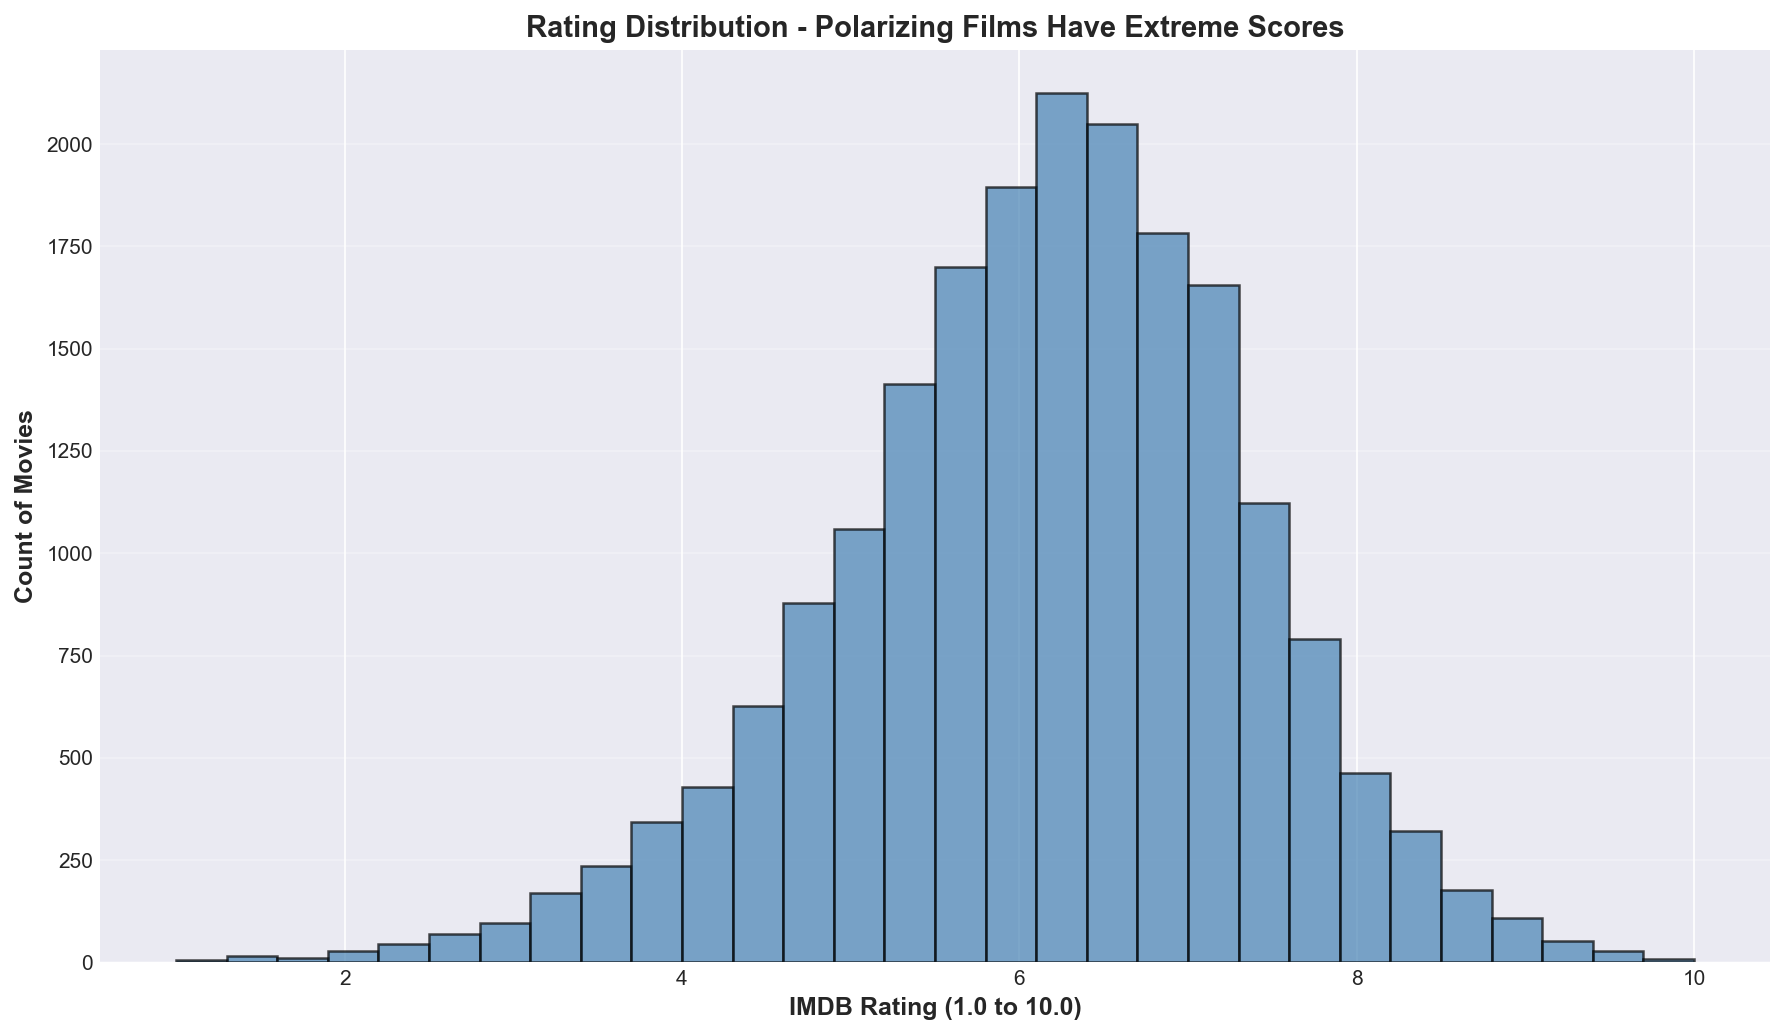

   ✓ Saved: 03_rating_distribution.png

📈 Graph 4/8: Engagement Distribution...


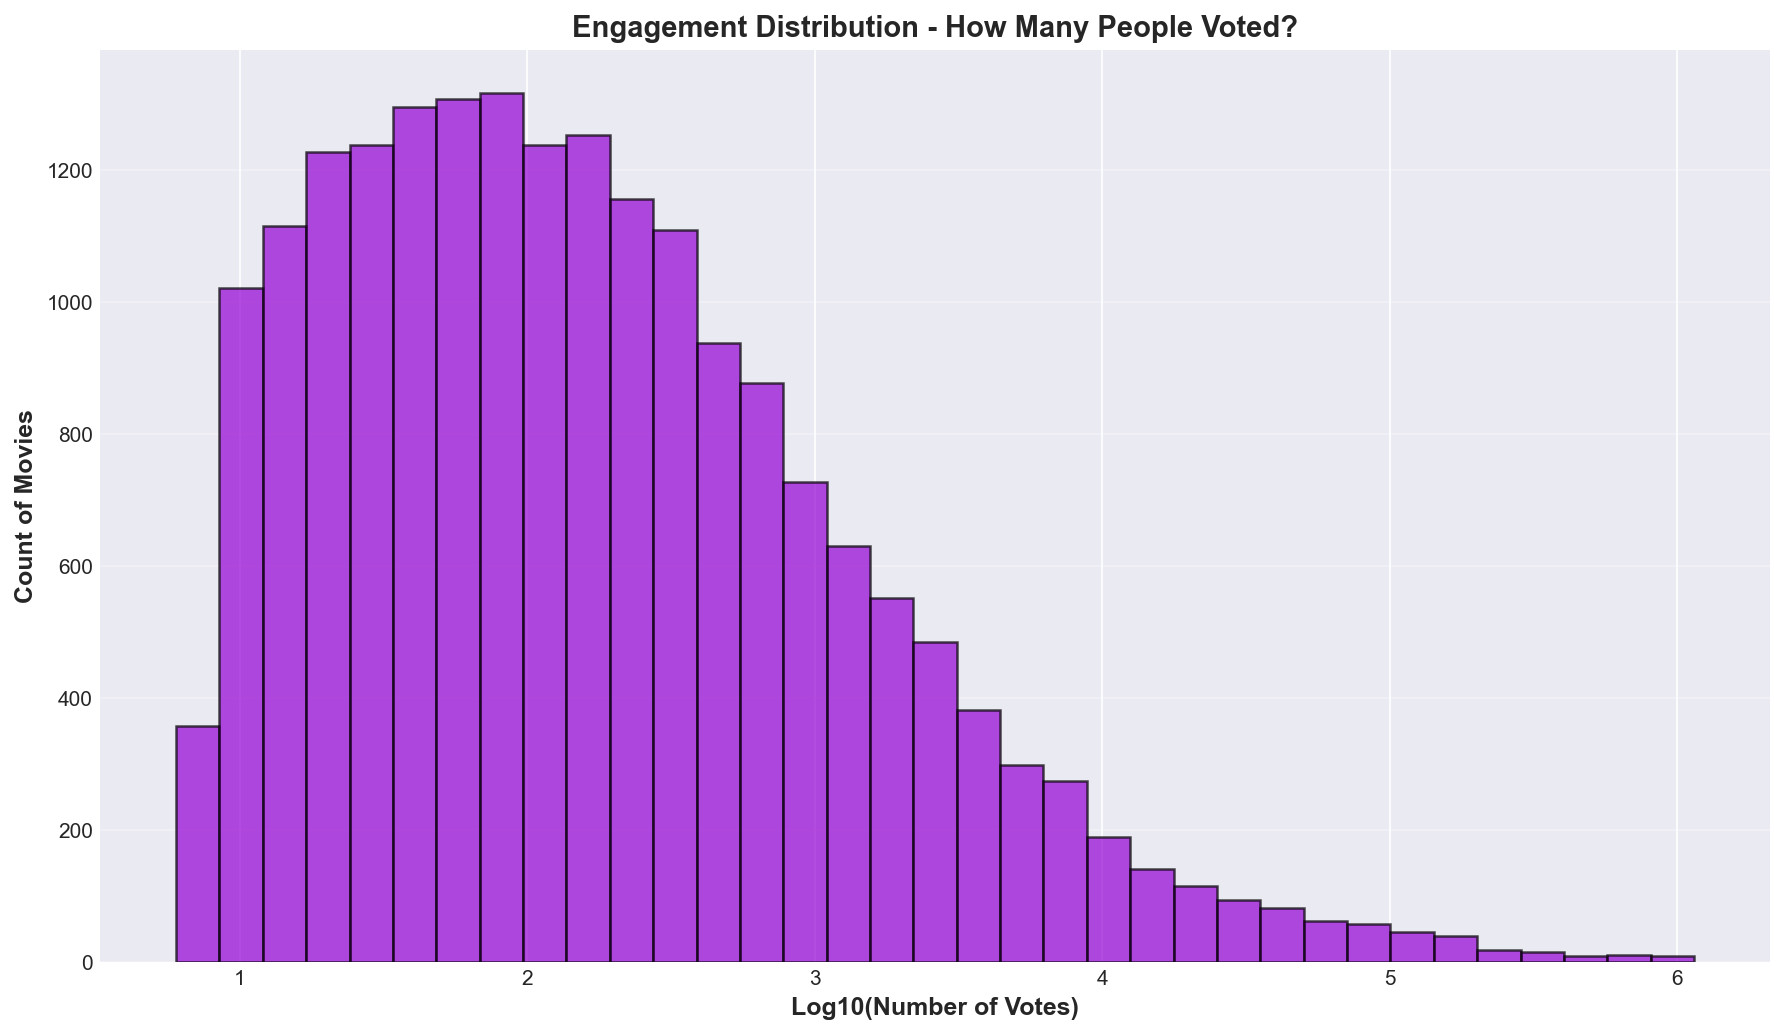

   ✓ Saved: 04_votes_distribution_log.png

📈 Graph 5/8: Rating vs Controversy Correlation...


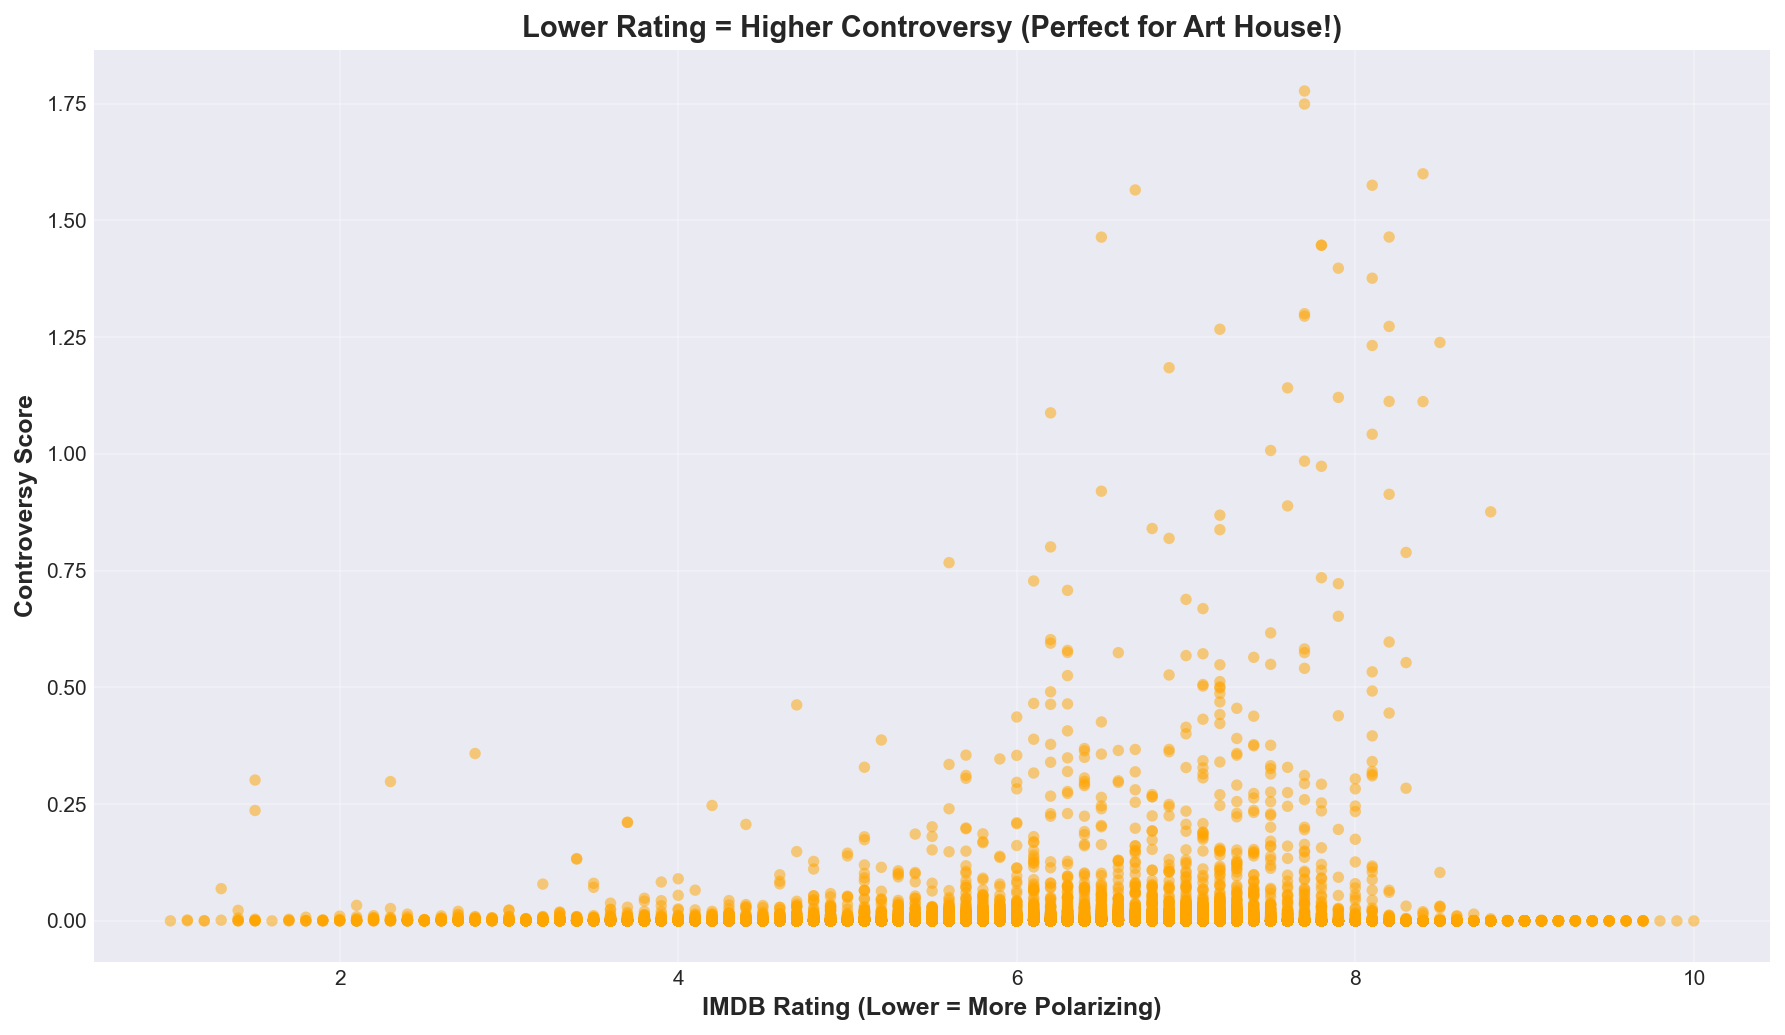

   ✓ Saved: 05_rating_vs_controversy.png

📈 Graph 6/8: Votes vs Controversy...


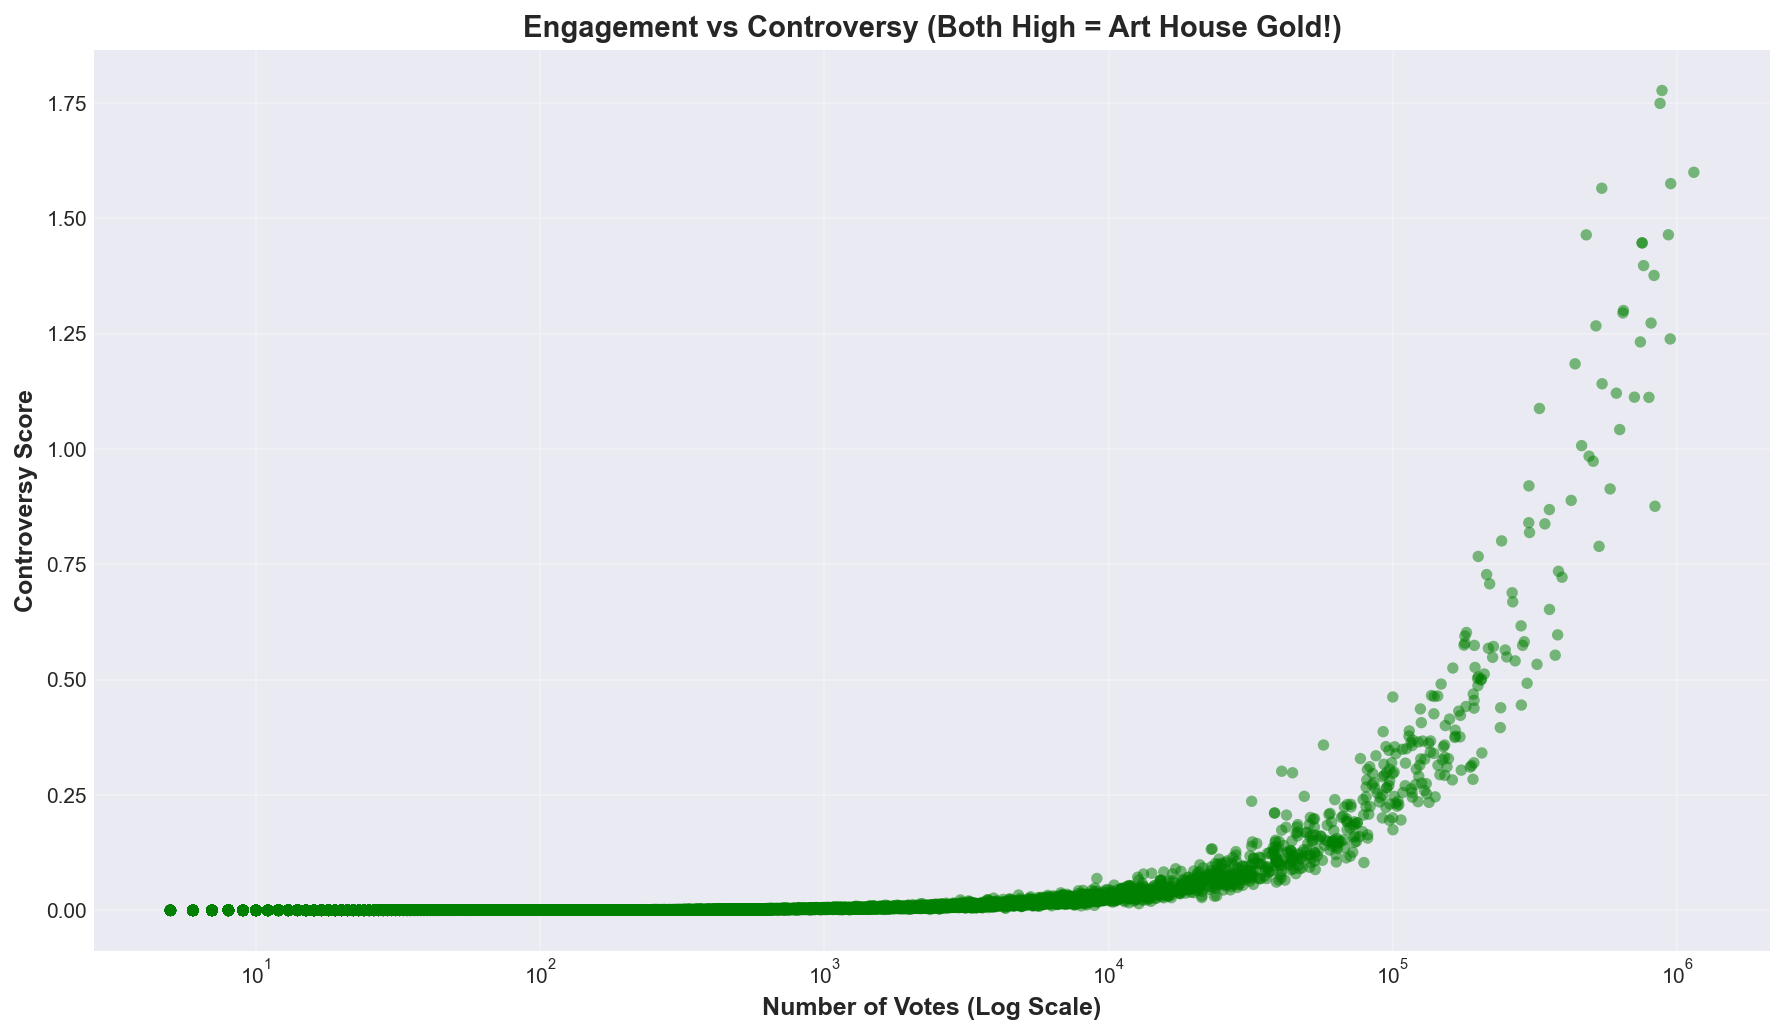

   ✓ Saved: 06_votes_vs_controversy.png

📈 Graph 7/8: Votes vs Rating Heatmap...


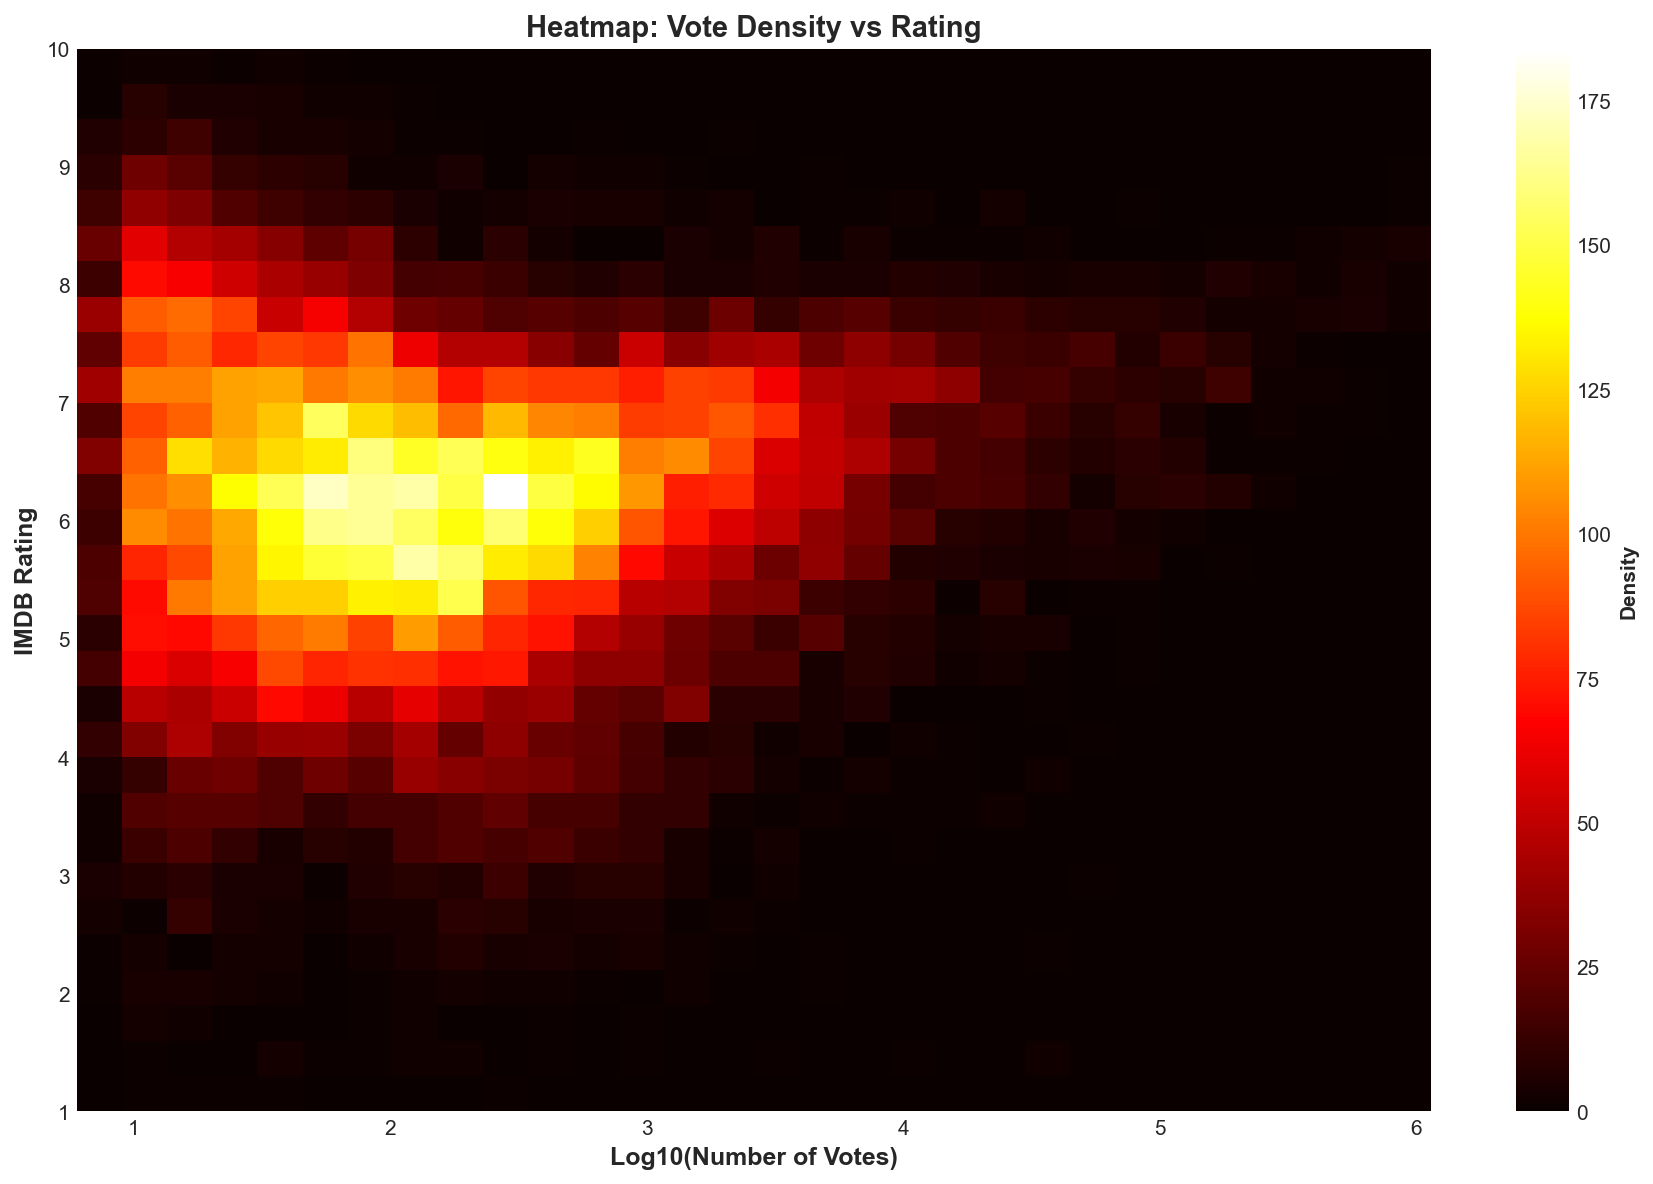

   ✓ Saved: 07_votes_rating_heatmap.png

📈 Graph 8/8: Keywords by Average Engagement...


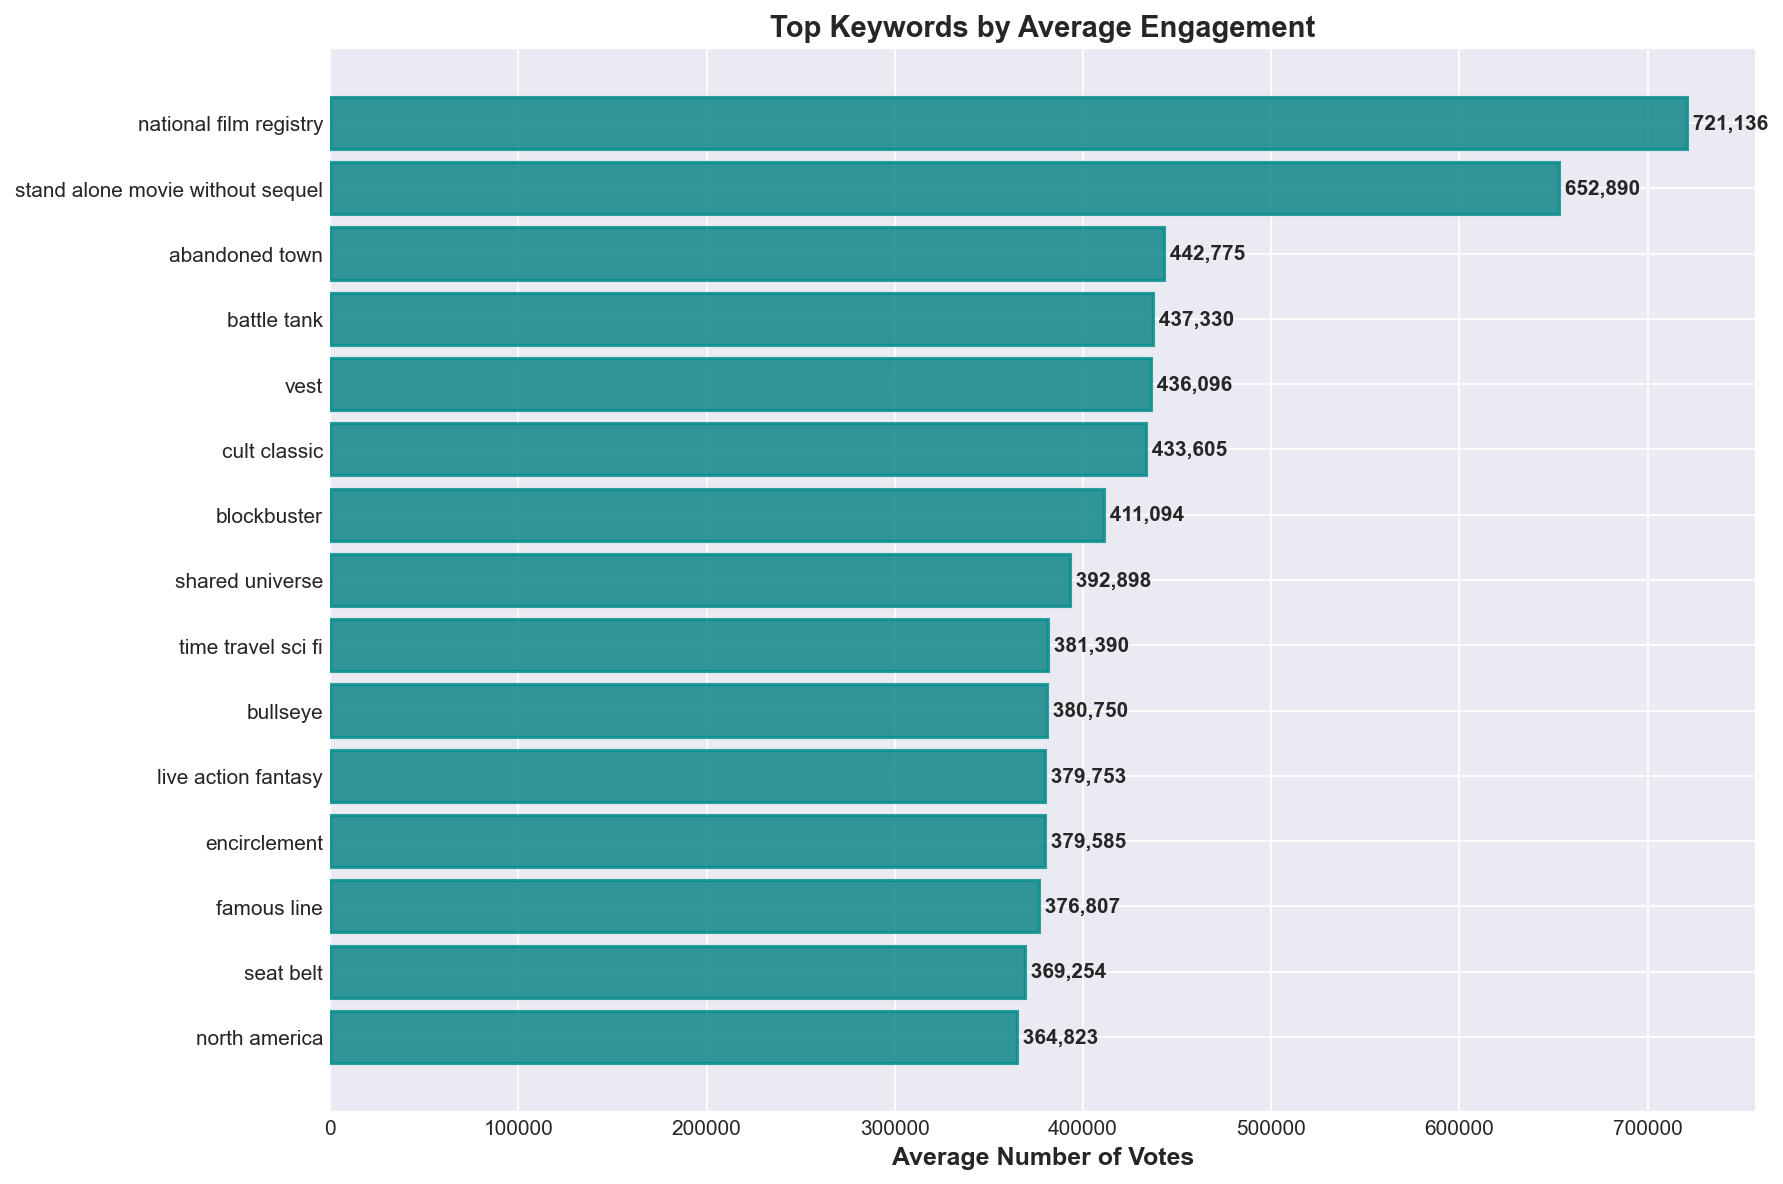

   ✓ Saved: 08_keywords_by_votes.png


✅ ANALYSIS COMPLETE!

🎬 KEY FINDINGS FOR ART HOUSE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Look for HIGH VOTES + LOW RATING (polarizing, controversial)
✓ These films generate STRONG REACTIONS from audiences
✓ Perfect for art house theaters that value bold, provocative content
✓ Check keywords list for niche/experimental themes
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 Generated 8 Visualizations (in 'movie_analysis_charts' folder):
  1️⃣  01_controversy_scatter.png - MAIN CHART: High votes + low rating
  2️⃣  02_controversial_keywords_bar.png - Keywords in controversial films
  3️⃣  03_rating_distribution.png - How ratings are distributed
  4️⃣  04_votes_distribution_log.png - Engagement patterns
  5️⃣  05_rating_vs_controversy.png - Direct correlation
  6️⃣  06_votes_vs_controversy.png - Engagement vs controversy
  7️⃣  07_votes_rating_heatmap.png - Density heatm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for beautiful plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("🎬 MOVIE DATASET ANALYSIS - ART HOUSE CONTROVERSY")
print("="*80)

# ============================================================================
# 1. LOAD DATA
# ============================================================================

print("\n📂 Loading data from Desktop...")
file_path = "/Users/alessiapapa/Desktop/Movie_50k.csv"
movies = pd.read_csv(file_path)

print(f"✓ Loaded: {len(movies)} movies with {len(movies.columns)} columns")
print(f"\nColumns: {list(movies.columns)}")

# ============================================================================
# 2. FILTER & CLEAN DATA
# ============================================================================

# Filter movies with complete data
movies_clean = movies[
    (movies['numberOfVotes'].notna()) &
    (movies['imdbRating'].notna()) &
    (movies['numberOfVotes'] > 0) &
    (movies['keywords'].notna()) &
    (movies['keywords'] != '')
].copy()

print(f"\n✓ Filtered to: {len(movies_clean)} movies with complete data")

# ============================================================================
# 3. CALCULATE CONTROVERSY SCORE
# ============================================================================

# Controversy = High votes + Low rating (polarizing)
max_votes = movies_clean['numberOfVotes'].max()
movies_clean['controversy_score'] = (
    (movies_clean['numberOfVotes'] / max_votes) * 
    (10 - movies_clean['imdbRating'])
)

# ============================================================================
# 4. TOP 30 MOST CONTROVERSIAL MOVIES
# ============================================================================

controversial_movies = movies_clean.nlargest(30, 'controversy_score')

print("\n" + "="*80)
print("🔥 TOP 30 MOST CONTROVERSIAL MOVIES (ART HOUSE GOLD)")
print("="*80)
print("(High votes + Low rating = POLARIZING, perfect for art house)\n")

for idx, (i, row) in enumerate(controversial_movies.iterrows(), 1):
    title = row['originalTitle']
    votes = int(row['numberOfVotes'])
    rating = row['imdbRating']
    keywords = row['keywords'][:70]
    controversy = row['controversy_score']
    
    print(f"{idx}. \"{title}\"")
    print(f"   🗳️  Votes: {votes:,} | ⭐ Rating: {rating} | 🔥 Controversy: {controversy:.2f}")
    print(f"   🔑 Keywords: {keywords}...")
    print()

# ============================================================================
# 5. ANALYZE KEYWORDS FOR CONTROVERSY
# ============================================================================

print("\n" + "="*80)
print("🔑 MOST CONTROVERSIAL KEYWORDS (Art House Appeal)")
print("="*80 + "\n")

keyword_stats = {}

for _, row in movies_clean.iterrows():
    keywords_str = row['keywords']
    votes = row['numberOfVotes']
    rating = row['imdbRating']
    controversy = row['controversy_score']
    
    # Split keywords by comma
    keywords_list = [kw.strip() for kw in str(keywords_str).split(',')]
    
    for kw in keywords_list:
        if kw and len(kw) > 2:
            if kw not in keyword_stats:
                keyword_stats[kw] = {
                    'count': 0,
                    'votes': [],
                    'ratings': [],
                    'controversies': []
                }
            
            keyword_stats[kw]['count'] += 1
            keyword_stats[kw]['votes'].append(votes)
            keyword_stats[kw]['ratings'].append(rating)
            keyword_stats[kw]['controversies'].append(controversy)

# Calculate averages and filter
keyword_analysis = {}
for kw, stats in keyword_stats.items():
    if stats['count'] >= 5:  # Only keywords with 5+ movies
        keyword_analysis[kw] = {
            'count': stats['count'],
            'avg_votes': np.mean(stats['votes']),
            'avg_rating': np.mean(stats['ratings']),
            'avg_controversy': np.mean(stats['controversies'])
        }

# Sort by controversy
sorted_keywords = sorted(keyword_analysis.items(), 
                         key=lambda x: x[1]['avg_controversy'], 
                         reverse=True)

print("🎭 Top 25 Keywords Associated with CONTROVERSIAL Content:\n")
for i, (kw, stats) in enumerate(sorted_keywords[:25], 1):
    print(f"{i}. '{kw}'")
    print(f"   📊 Movies: {stats['count']} | 🗳️  Avg Votes: {int(stats['avg_votes']):,} | ⭐ Avg Rating: {stats['avg_rating']:.2f} | 🔥 Controversy: {stats['avg_controversy']:.3f}")
    print()

# ============================================================================
# 6. CREATE VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("📊 CREATING VISUALIZATIONS")
print("="*80 + "\n")

# Create output directory
import os
os.makedirs("movie_analysis_charts", exist_ok=True)

# 1. SCATTER: Votes vs Rating (Main Analysis)
print("📈 Graph 1/8: Controversy Scatter Plot...")
fig, ax = plt.subplots(figsize=(14, 9), dpi=150)
scatter = ax.scatter(movies_clean['numberOfVotes'], 
                     movies_clean['imdbRating'],
                     c=movies_clean['controversy_score'],
                     s=30, alpha=0.6, cmap='hot', edgecolors='none')
ax.set_xlabel('Number of Votes (Log Scale)', fontsize=12, fontweight='bold')
ax.set_ylabel('IMDB Rating (Lower = More Controversial)', fontsize=12, fontweight='bold')
ax.set_title('🔥 CONTROVERSIAL MOVIES: High Votes + Low Rating', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Controversy Score', fontweight='bold')
plt.tight_layout()
plt.savefig('movie_analysis_charts/01_controversy_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Saved: 01_controversy_scatter.png\n")

# 2. BAR CHART: Top Controversial Keywords
print("📈 Graph 2/8: Top Controversial Keywords...")
top_kws = sorted_keywords[:15]
kw_names = [kw[0] for kw in top_kws]
kw_scores = [kw[1]['avg_controversy'] for kw in top_kws]

fig, ax = plt.subplots(figsize=(12, 8), dpi=150)
bars = ax.barh(kw_names, kw_scores, color='crimson', alpha=0.8, edgecolor='darkred', linewidth=1.5)
ax.set_xlabel('Average Controversy Score', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Keywords in CONTROVERSIAL Films', fontsize=14, fontweight='bold')
ax.invert_yaxis()
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f' {width:.3f}', ha='left', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('movie_analysis_charts/02_controversial_keywords_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Saved: 02_controversial_keywords_bar.png\n")

# 3. HISTOGRAM: Rating Distribution
print("📈 Graph 3/8: Rating Distribution...")
fig, ax = plt.subplots(figsize=(12, 7), dpi=150)
ax.hist(movies_clean['imdbRating'], bins=30, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.2)
ax.set_xlabel('IMDB Rating (1.0 to 10.0)', fontsize=12, fontweight='bold')
ax.set_ylabel('Count of Movies', fontsize=12, fontweight='bold')
ax.set_title('Rating Distribution - Polarizing Films Have Extreme Scores', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('movie_analysis_charts/03_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Saved: 03_rating_distribution.png\n")

# 4. HISTOGRAM: Votes Distribution (Log Scale)
print("📈 Graph 4/8: Engagement Distribution...")
fig, ax = plt.subplots(figsize=(12, 7), dpi=150)
ax.hist(np.log10(movies_clean['numberOfVotes'] + 1), bins=35, 
        color='darkviolet', alpha=0.7, edgecolor='black', linewidth=1.2)
ax.set_xlabel('Log10(Number of Votes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Count of Movies', fontsize=12, fontweight='bold')
ax.set_title('Engagement Distribution - How Many People Voted?', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('movie_analysis_charts/04_votes_distribution_log.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Saved: 04_votes_distribution_log.png\n")

# 5. SCATTER: Rating vs Controversy
print("📈 Graph 5/8: Rating vs Controversy Correlation...")
fig, ax = plt.subplots(figsize=(12, 7), dpi=150)
ax.scatter(movies_clean['imdbRating'], movies_clean['controversy_score'],
           c='orange', alpha=0.5, s=30, edgecolors='none')
ax.set_xlabel('IMDB Rating (Lower = More Polarizing)', fontsize=12, fontweight='bold')
ax.set_ylabel('Controversy Score', fontsize=12, fontweight='bold')
ax.set_title('Lower Rating = Higher Controversy (Perfect for Art House!)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('movie_analysis_charts/05_rating_vs_controversy.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Saved: 05_rating_vs_controversy.png\n")

# 6. SCATTER: Votes vs Controversy
print("📈 Graph 6/8: Votes vs Controversy...")
fig, ax = plt.subplots(figsize=(12, 7), dpi=150)
ax.scatter(movies_clean['numberOfVotes'], movies_clean['controversy_score'],
           c='green', alpha=0.5, s=30, edgecolors='none')
ax.set_xscale('log')
ax.set_xlabel('Number of Votes (Log Scale)', fontsize=12, fontweight='bold')
ax.set_ylabel('Controversy Score', fontsize=12, fontweight='bold')
ax.set_title('Engagement vs Controversy (Both High = Art House Gold!)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('movie_analysis_charts/06_votes_vs_controversy.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Saved: 06_votes_vs_controversy.png\n")

# 7. 2D HISTOGRAM (Heatmap)
print("📈 Graph 7/8: Votes vs Rating Heatmap...")
fig, ax = plt.subplots(figsize=(12, 8), dpi=150)
h = ax.hist2d(np.log10(movies_clean['numberOfVotes'] + 1), 
              movies_clean['imdbRating'],
              bins=30, cmap='hot')
ax.set_xlabel('Log10(Number of Votes)', fontsize=12, fontweight='bold')
ax.set_ylabel('IMDB Rating', fontsize=12, fontweight='bold')
ax.set_title('Heatmap: Vote Density vs Rating', fontsize=14, fontweight='bold')
cbar = plt.colorbar(h[3], ax=ax)
cbar.set_label('Density', fontweight='bold')
plt.tight_layout()
plt.savefig('movie_analysis_charts/07_votes_rating_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Saved: 07_votes_rating_heatmap.png\n")

# 8. BAR CHART: Keywords by Average Votes
print("📈 Graph 8/8: Keywords by Average Engagement...")
top_kws_votes = sorted(keyword_analysis.items(), 
                       key=lambda x: x[1]['avg_votes'], 
                       reverse=True)[:15]
kw_names_votes = [kw[0] for kw in top_kws_votes]
kw_avg_votes = [kw[1]['avg_votes'] for kw in top_kws_votes]

fig, ax = plt.subplots(figsize=(12, 8), dpi=150)
bars = ax.barh(kw_names_votes, kw_avg_votes, color='teal', alpha=0.8, edgecolor='darkcyan', linewidth=1.5)
ax.set_xlabel('Average Number of Votes', fontsize=12, fontweight='bold')
ax.set_title('Top Keywords by Average Engagement', fontsize=14, fontweight='bold')
ax.invert_yaxis()
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f' {int(width):,}', ha='left', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('movie_analysis_charts/08_keywords_by_votes.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✓ Saved: 08_keywords_by_votes.png\n")

# ============================================================================
# 7. SUMMARY
# ============================================================================

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE!")
print("="*80)

print("\n🎬 KEY FINDINGS FOR ART HOUSE:")
print("━" * 80)
print("✓ Look for HIGH VOTES + LOW RATING (polarizing, controversial)")
print("✓ These films generate STRONG REACTIONS from audiences")
print("✓ Perfect for art house theaters that value bold, provocative content")
print("✓ Check keywords list for niche/experimental themes")
print("━" * 80)

print("\n📊 Generated 8 Visualizations (in 'movie_analysis_charts' folder):")
print("  1️⃣  01_controversy_scatter.png - MAIN CHART: High votes + low rating")
print("  2️⃣  02_controversial_keywords_bar.png - Keywords in controversial films")
print("  3️⃣  03_rating_distribution.png - How ratings are distributed")
print("  4️⃣  04_votes_distribution_log.png - Engagement patterns")
print("  5️⃣  05_rating_vs_controversy.png - Direct correlation")
print("  6️⃣  06_votes_vs_controversy.png - Engagement vs controversy")
print("  7️⃣  07_votes_rating_heatmap.png - Density heatmap")
print("  8️⃣  08_keywords_by_votes.png - Keywords by engagement")

print("\n💡 PRO TIP FOR ART HOUSE:")
print("Films in the UPPER-LEFT of scatter plots are your GOLD:")
print("  • High number of votes (engaged audience)")
print("  • Low rating (controversial/polarizing)")
print("  • These spark DEBATE and discussion! 🔥")

print("\n🎭 All images saved to: movie_analysis_charts/")
print("\n")